In [ ]:
Student Name : Kirti Mukesh Chaudhari
Div : A
Practical Batch : A-1
Roll No : 25
Date : 2/09/2026
Practical No : 01
Practical Name : Implement simple and multiple linear regression using Numpy and using
                 Sckit-learn. Plot regression lines and residuals.Compute RMSE and R2 values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = {
    "Study_Hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Attendance": [60, 85, 70, 95, 65, 80, 90, 75, 88, 72],
    "Marks": [32, 42, 47, 58, 61, 67, 76, 79, 88, 91]
}

df = pd.DataFrame(data)

print(df)

   Study_Hours  Attendance  Marks
0            1          60     32
1            2          85     42
2            3          70     47
3            4          95     58
4            5          65     61
5            6          80     67
6            7          90     76
7            8          75     79
8            9          88     88
9           10          72     91


In [3]:
print("First Five Rows:")
print(df.head())

print("\nShape of Dataset:")
print(df.shape)

print("\nInformation:")
df.info()

print("\nStatistical Analysis:")
print(df.describe())

print("\nCheck for null values:")
print(df.isnull().sum())

print("\nDuplicate Values:")
print(df.duplicated().sum())

df = df.drop_duplicates()

First Five Rows:
   Study_Hours  Attendance  Marks
0            1          60     32
1            2          85     42
2            3          70     47
3            4          95     58
4            5          65     61

Shape of Dataset:
(10, 3)

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Study_Hours  10 non-null     int64
 1   Attendance   10 non-null     int64
 2   Marks        10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes

Statistical Analysis:
       Study_Hours  Attendance      Marks
count     10.00000   10.000000  10.000000
mean       5.50000   78.000000  64.100000
std        3.02765   11.489125  19.790289
min        1.00000   60.000000  32.000000
25%        3.25000   70.500000  49.750000
50%        5.50000   77.500000  64.000000
75%        7.75000   87.250000  78.250000
max       10.00000   95.000000  91.

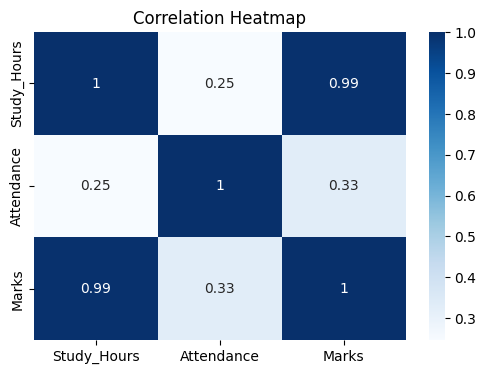

In [4]:
plt.figure(figsize=(6, 4))

df_corr = df.corr()

sns.heatmap(df_corr, annot=True, cmap='Blues')

plt.title("Correlation Heatmap")
plt.show()

In [5]:
x = df[['Study_Hours']]
y = df['Marks']

In [6]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

print("Testing Data:")
print(x_test)

Testing Data:
   Study_Hours
8            9
1            2
5            6


In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train, y_train)

LinearRegression()

In [8]:
y_pred = model.predict(x_test)

print("Predicted Values:")
print(y_pred)

Predicted Values:
[86.55445545 41.22772277 67.12871287]


In [9]:
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 28.277227722772274
Slope: 6.475247524752477


In [10]:
Intercept: 28.2772
Slope: 6.4752

In [11]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", round(rmse, 3))
print("R2 Score:", round(r2, 3))

RMSE: 0.949
R2 Score: 0.997


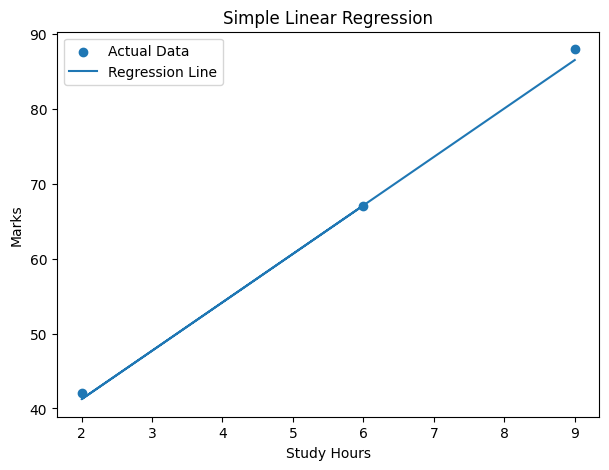

In [12]:
plt.figure(figsize=(7, 5))

plt.scatter(x_test, y_test, label='Actual Data')
plt.plot(x_test, y_pred, label='Regression Line')

plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Simple Linear Regression')
plt.legend()

plt.show()

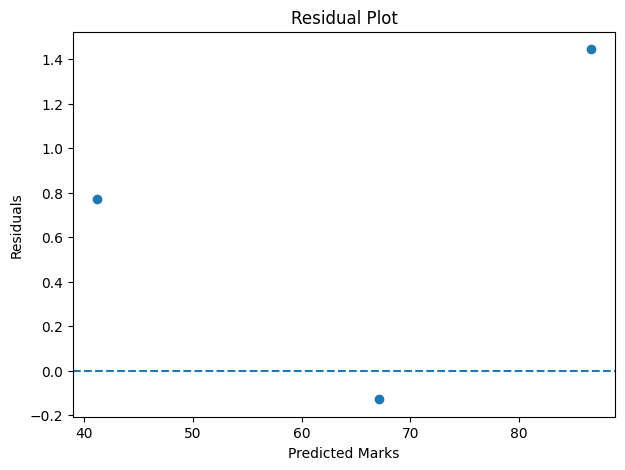

In [13]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))

plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Marks')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

In [14]:
x = df["Study_Hours"].values
y = df["Marks"].values

x_mean = np.mean(x)
y_mean = np.mean(y)

In [15]:
m = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)

b = y_mean - m * x_mean

print("Slope =", m)
print("Intercept =", b)

Slope = 6.503030303030303
Intercept = 28.33333333333333


In [16]:
y_pred_numpy = m * x + b

print("Predicted Values:")
print(y_pred_numpy)

Predicted Values:
[34.83636364 41.33939394 47.84242424 54.34545455 60.84848485 67.35151515
 73.85454545 80.35757576 86.86060606 93.36363636]


In [17]:
x = df[['Study_Hours', 'Attendance']]
y = df['Marks']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [18]:
model = LinearRegression()

model.fit(x_train, y_train)

LinearRegression()

In [19]:
y_pred = model.predict(x_test)

print("Predicted Values:")
print(y_pred)

Predicted Values:
[88.08653885 43.59718321 67.84336712]


In [20]:
print("Intercept:", model.intercept_)

coeff = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_
})

print(coeff)

Intercept: 16.14458419831481
       Feature  Coefficient
0  Study_Hours     6.280539
1   Attendance     0.175194


In [21]:
Intercept: 16.14

Study_Hours: 6.28
Attendance: 0.18

In [22]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 2))

RMSE: 1.04
R2 Score: 1.0


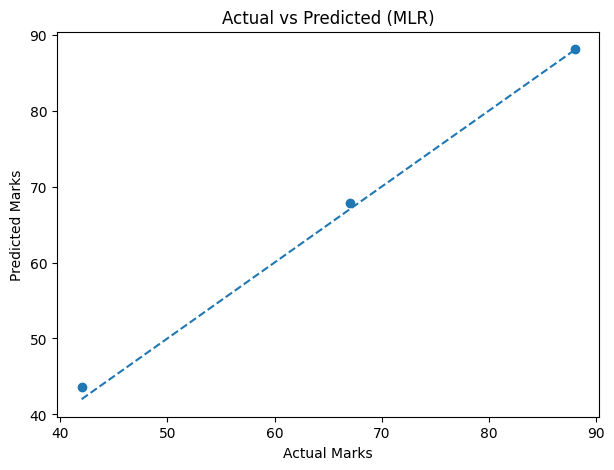

In [24]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual Marks')
plt.ylabel('Predicted Marks')
plt.title('Actual vs Predicted (MLR)')

plt.show()

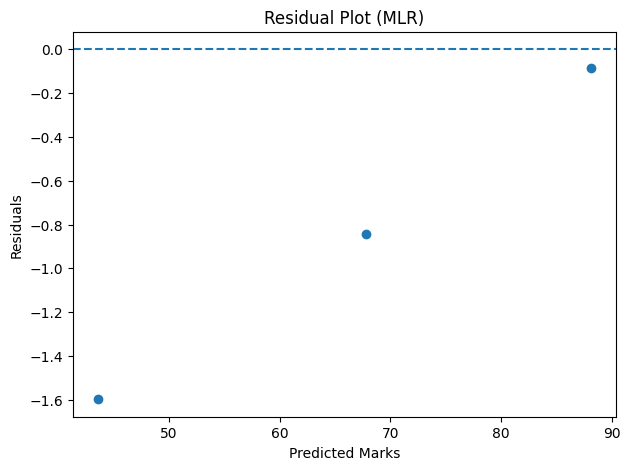

In [25]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))

plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Marks')
plt.ylabel('Residuals')
plt.title('Residual Plot (MLR)')

plt.show()